## Анализ сгенерированных данных для обучения

В этом ноутбуке мы смотрим на `train_data2.csv`: ищем самую низкую частоту, на которой есть положительный band gap, максимальный band gap по ширине и смотрим, как band gap распределяется по каждому признаку.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.linalg import eigh

PROJECT_ROOT = Path("/Users/grigorijevgenev/Desktop/CourseWorkPINN")
DATASET_NAME = "train_data.csv"
DATASET_PATH = PROJECT_ROOT / "data/generated_data" / DATASET_NAME

FEATURE_COLS = ["E", "nu", "rho", "h", "a", "mR", "fR_target"]
GAP_COLS = ["f_low", "f_high", "gap_width", "gap_center"]

df = pd.read_csv(DATASET_PATH)
df["gap_width"] = df["f_high"] - df["f_low"]
df["gap_center"] = 0.5 * (df["f_low"] + df["f_high"])

positive_gap_df = df[df["gap_width"] > 1e-9].copy()

print(f"Dataset path: {DATASET_PATH}")
print(f"All rows: {len(df)}")
print(f"Rows with positive gap: {len(positive_gap_df)}")
print(f"Rows with zero / non-positive gap: {len(df) - len(positive_gap_df)}")

display(df.head())

Dataset path: /Users/grigorijevgenev/Desktop/CourseWorkPINN/data/generated_data/train_data.csv
All rows: 2000
Rows with positive gap: 1994
Rows with zero / non-positive gap: 6


,E,nu,rho,h,a,mR,fR_target,f_low,f_high,gap_width,gap_center
0,9.630968e+10,0.329163,2642.550886,0.001717,0.119557,0.031151,130.383557,125.575713,156.669019,31.093306,141.122366
1,8.286898e+10,0.299733,2605.541242,0.002143,0.112032,0.020116,361.487197,326.284193,395.924962,69.640770,361.104577
2,9.701753e+10,0.329928,2686.814968,0.001507,0.108666,0.023719,420.351874,307.932175,368.392046,60.459871,338.162110
3,7.423335e+10,0.323329,2697.560106,0.002444,0.115342,0.022312,73.635113,73.367114,82.373265,9.006152,77.870189
4,9.068424e+10,0.313861,2719.252342,0.001708,0.088358,0.022337,178.988255,173.674454,225.263013,51.588559,199.468734


## Экстремальные случаи

Сначала посмотрим на два самых интересных примера:
- минимальную частоту `f_low`, где band gap вообще есть;
- максимальную ширину `gap_width`.

In [2]:
min_freq_row = positive_gap_df.loc[positive_gap_df["f_low"].idxmin()]
max_width_row = positive_gap_df.loc[positive_gap_df["gap_width"].idxmax()]

print("Самая маленькая частота, на которой есть положительный band gap:")
display(pd.DataFrame([min_freq_row])[FEATURE_COLS + ["f_low", "f_high", "gap_width", "gap_center"]])

print("Максимальный band gap по ширине:")
display(pd.DataFrame([max_width_row])[FEATURE_COLS + ["f_low", "f_high", "gap_width", "gap_center"]])

Самая маленькая частота, на которой есть положительный band gap:


,E,nu,rho,h,a,mR,fR_target,f_low,f_high,gap_width,gap_center
1926,7.299577e+10,0.325199,2799.436888,0.00207,0.089095,0.020817,30.158894,30.141767,36.342655,6.200888,33.242211


Максимальный band gap по ширине:


,E,nu,rho,h,a,mR,fR_target,f_low,f_high,gap_width,gap_center
1480,6.815508e+10,0.328324,2639.433024,0.001749,0.082162,0.03392,496.262224,368.130166,625.445975,257.315809,496.78807


In [3]:
print("Топ-10 по самой низкой частоте f_low:")
display(
    positive_gap_df
    .nsmallest(10, "f_low")[FEATURE_COLS + ["f_low", "f_high", "gap_width"]]
    .reset_index(drop=True)
)

print("Топ-10 по максимальной ширине gap_width:")
display(
    positive_gap_df
    .nlargest(10, "gap_width")[FEATURE_COLS + ["f_low", "f_high", "gap_width"]]
    .reset_index(drop=True)
)

Топ-10 по самой низкой частоте f_low:


,E,nu,rho,h,a,mR,fR_target,f_low,f_high,gap_width
0,7.299577e+10,0.325199,2799.436888,0.002070,0.089095,0.020817,30.158894,30.141767,36.342655,6.200888
1,6.160437e+10,0.311412,2788.962438,0.001621,0.115075,0.020096,30.432089,30.361500,35.145110,4.783610
2,1.077195e+11,0.282077,2798.491883,0.002117,0.101278,0.023771,30.658969,30.641674,36.154175,5.512501
3,8.934179e+10,0.306365,2705.954006,0.002280,0.119556,0.033588,31.203575,31.169445,36.654972,5.485527
4,8.663987e+10,0.306506,2739.303888,0.002419,0.119740,0.022281,31.472313,31.452178,34.961758,3.509580
5,7.308452e+10,0.322879,2643.071050,0.001659,0.099443,0.022732,32.327064,32.271349,39.890053,7.618705
6,1.071339e+11,0.288511,2678.733435,0.002415,0.119668,0.022647,32.290508,32.272371,36.014682,3.742311
7,7.153571e+10,0.326436,2644.023289,0.001961,0.096377,0.028815,32.455180,32.413789,41.013690,8.599901
8,1.002795e+11,0.274230,2796.363922,0.002354,0.088364,0.020541,32.501070,32.490424,38.446978,5.956554
9,9.497860e+10,0.321165,2660.183782,0.002061,0.110966,0.024027,33.054437,33.022949,38.476606,5.453657


Топ-10 по максимальной ширине gap_width:


,E,nu,rho,h,a,mR,fR_target,f_low,f_high,gap_width
0,6.815508e+10,0.328324,2639.433024,0.001749,0.082162,0.033920,496.262224,368.130166,625.445975,257.315809
1,1.055049e+11,0.300556,2700.440770,0.001664,0.083701,0.033162,476.039898,379.224894,623.521855,244.296961
2,6.922335e+10,0.271949,2622.601875,0.001687,0.080119,0.028795,486.718984,370.855526,614.548380,243.692854
3,7.900907e+10,0.283548,2634.213464,0.001906,0.082056,0.032891,499.986986,402.086480,644.971993,242.885513
4,1.093523e+11,0.299013,2693.545155,0.001737,0.086625,0.034820,483.358691,385.898670,624.127281,238.228611
5,9.404765e+10,0.324603,2628.375971,0.001648,0.083596,0.034296,437.537062,349.442896,585.040518,235.597622
6,8.328364e+10,0.306645,2623.258590,0.001624,0.082086,0.027095,485.809523,378.342576,610.862599,232.520023
7,7.165193e+10,0.316366,2667.177310,0.001592,0.082218,0.029062,448.387775,341.063434,565.211735,224.148302
8,8.010671e+10,0.286225,2610.339108,0.001600,0.085033,0.034449,403.832501,312.923936,532.230413,219.306476
9,8.113163e+10,0.275175,2754.427457,0.001775,0.083122,0.030617,471.608105,376.826840,595.824589,218.997748


## Краткая статистика по положительным gap-ам

In [4]:
summary = positive_gap_df[FEATURE_COLS + GAP_COLS].describe().loc[["min", "25%", "50%", "75%", "max"]]
display(summary)

,E,nu,rho,h,a,mR,fR_target,f_low,f_high,gap_width,gap_center
min,6.000934e+10,0.270044,2600.053626,0.001501,0.080044,0.020014,30.158894,30.141767,34.961758,0.525439,32.753305
25%,7.296117e+10,0.284493,2647.570402,0.001749,0.090058,0.023535,146.743361,143.531303,180.655325,32.254063,162.386259
50%,8.566382e+10,0.299557,2697.693544,0.002002,0.100422,0.027131,264.193044,241.861422,309.358519,61.986156,275.682282
75%,9.786016e+10,0.315046,2748.419779,0.002253,0.110075,0.031030,389.433609,324.974800,422.157925,101.660138,374.528204
max,1.099961e+11,0.330000,2799.907355,0.002499,0.119923,0.034998,499.986986,459.803870,644.971993,257.315809,534.294597


## Распределения самих band gap-ов

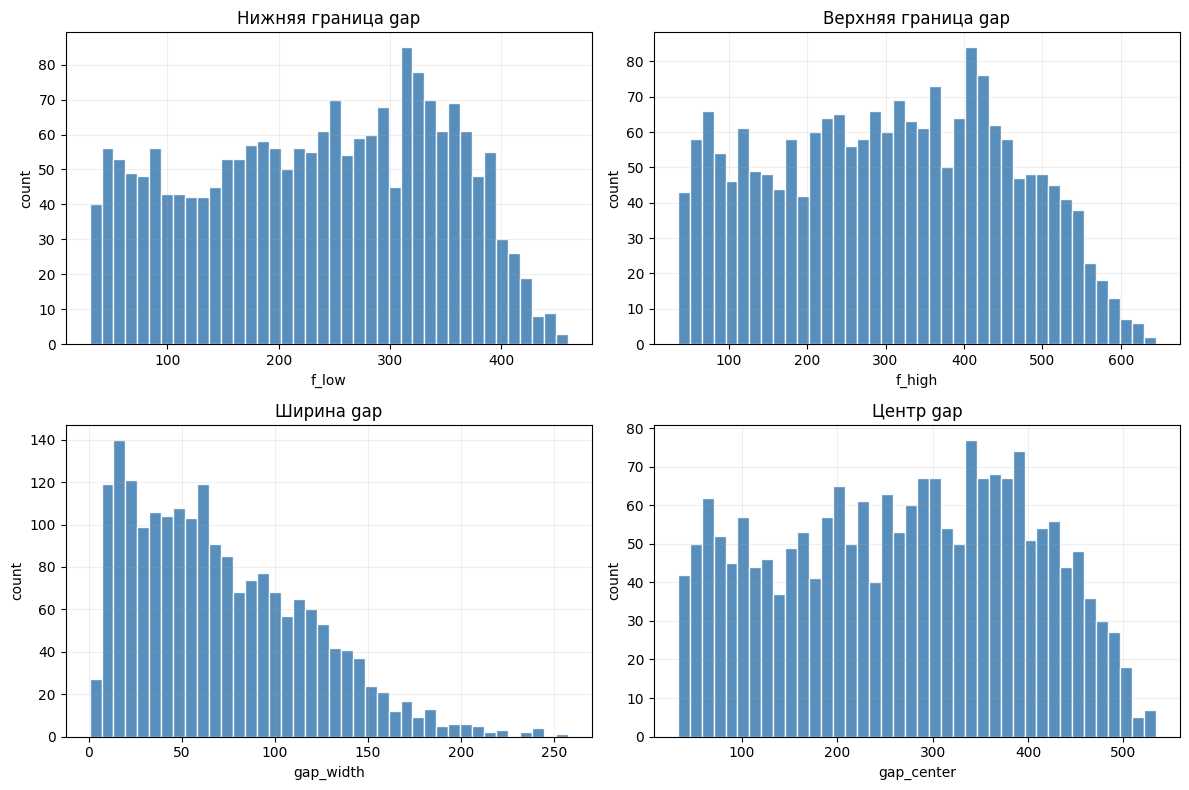

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    ("f_low", "Нижняя граница gap"),
    ("f_high", "Верхняя граница gap"),
    ("gap_width", "Ширина gap"),
    ("gap_center", "Центр gap"),
]

for ax, (column, title) in zip(axes.flatten(), plots):
    ax.hist(positive_gap_df[column], bins=40, color="steelblue", edgecolor="white", alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("count")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Корреляция признаков с band gap-метриками

In [6]:
corr_table = positive_gap_df[FEATURE_COLS + GAP_COLS].corr(numeric_only=True).loc[FEATURE_COLS, GAP_COLS]
display(corr_table.style.background_gradient(cmap="coolwarm").format("{:.3f}"))

,f_low,f_high,gap_width,gap_center
E,0.044,0.046,0.042,0.045
nu,-0.001,-0.007,-0.019,-0.004
rho,-0.029,-0.035,-0.044,-0.032
h,0.086,0.024,-0.123,0.051
a,-0.094,-0.195,-0.403,-0.153
mR,-0.036,0.034,0.192,0.005
fR_target,0.980,0.959,0.778,0.972


## Распределение band gap-ов по каждому признаку

Ниже три набора графиков:
- как меняется `gap_width` по признакам;
- как меняется `f_low` по признакам;
- как меняется `f_high` по признакам.

In [7]:
def plot_feature_vs_gap_metric(data: pd.DataFrame, metric: str, feature_cols: list[str] = FEATURE_COLS, gridsize: int = 28) -> None:
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    axes = axes.flatten()

    for ax, feature in zip(axes, feature_cols):
        hb = ax.hexbin(
            data[feature],
            data[metric],
            gridsize=gridsize,
            cmap="viridis",
            mincnt=1,
        )
        ax.set_title(f"{feature} vs {metric}")
        ax.set_xlabel(feature)
        ax.set_ylabel(metric)
        ax.grid(alpha=0.15)
        fig.colorbar(hb, ax=ax, label="count")

    for ax in axes[len(feature_cols):]:
        ax.axis("off")

    fig.suptitle(f"Распределение {metric} по признакам", fontsize=16)
    fig.tight_layout()
    plt.show()

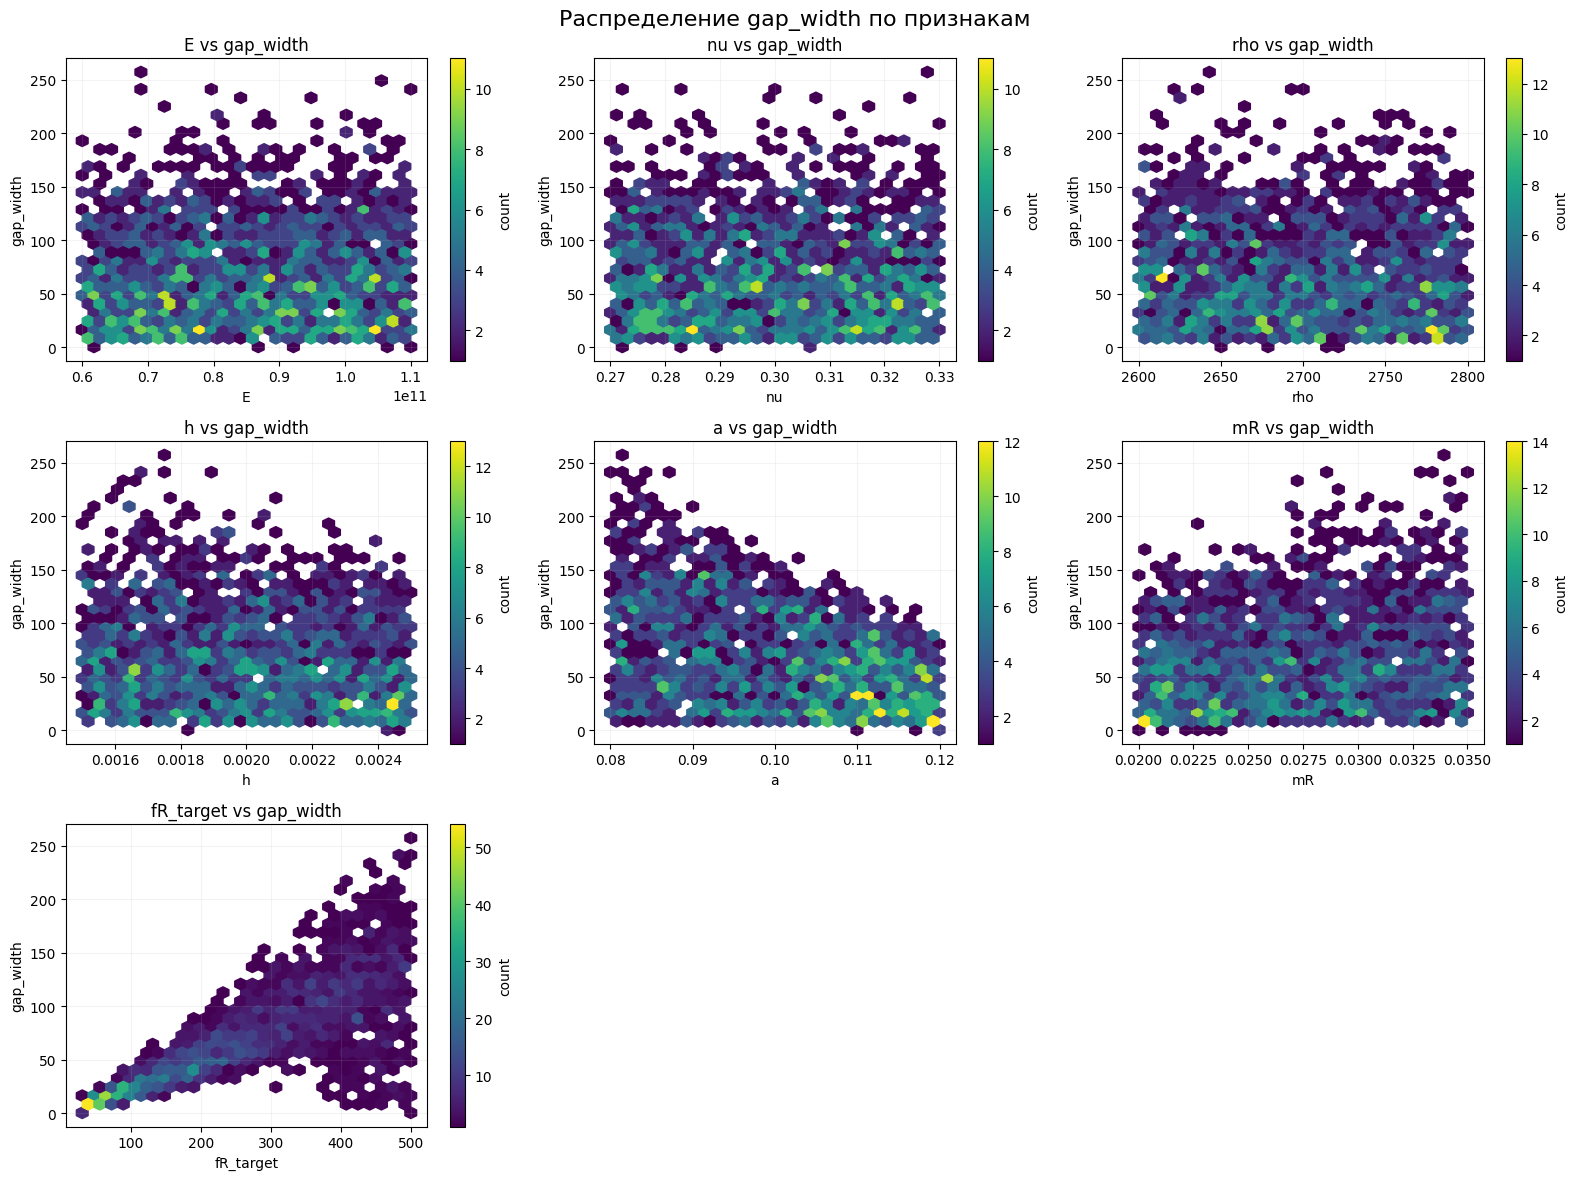

In [8]:
plot_feature_vs_gap_metric(positive_gap_df, "gap_width")

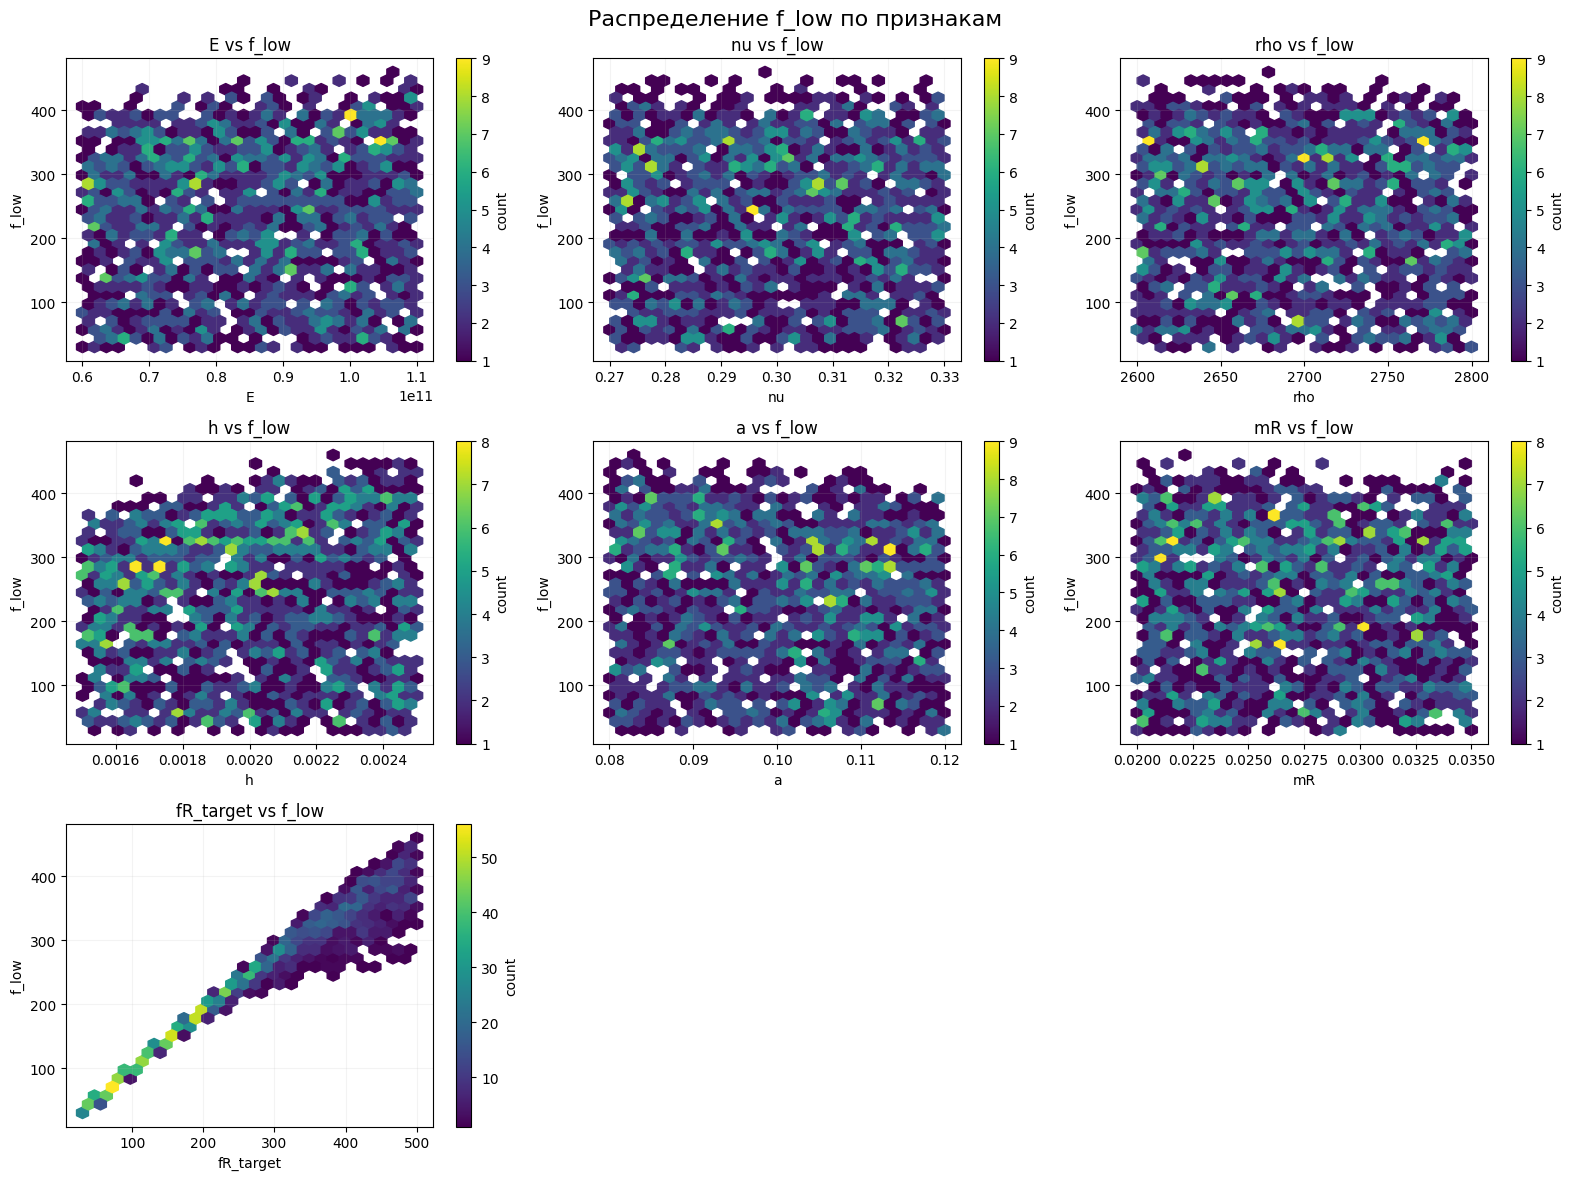

In [9]:
plot_feature_vs_gap_metric(positive_gap_df, "f_low")

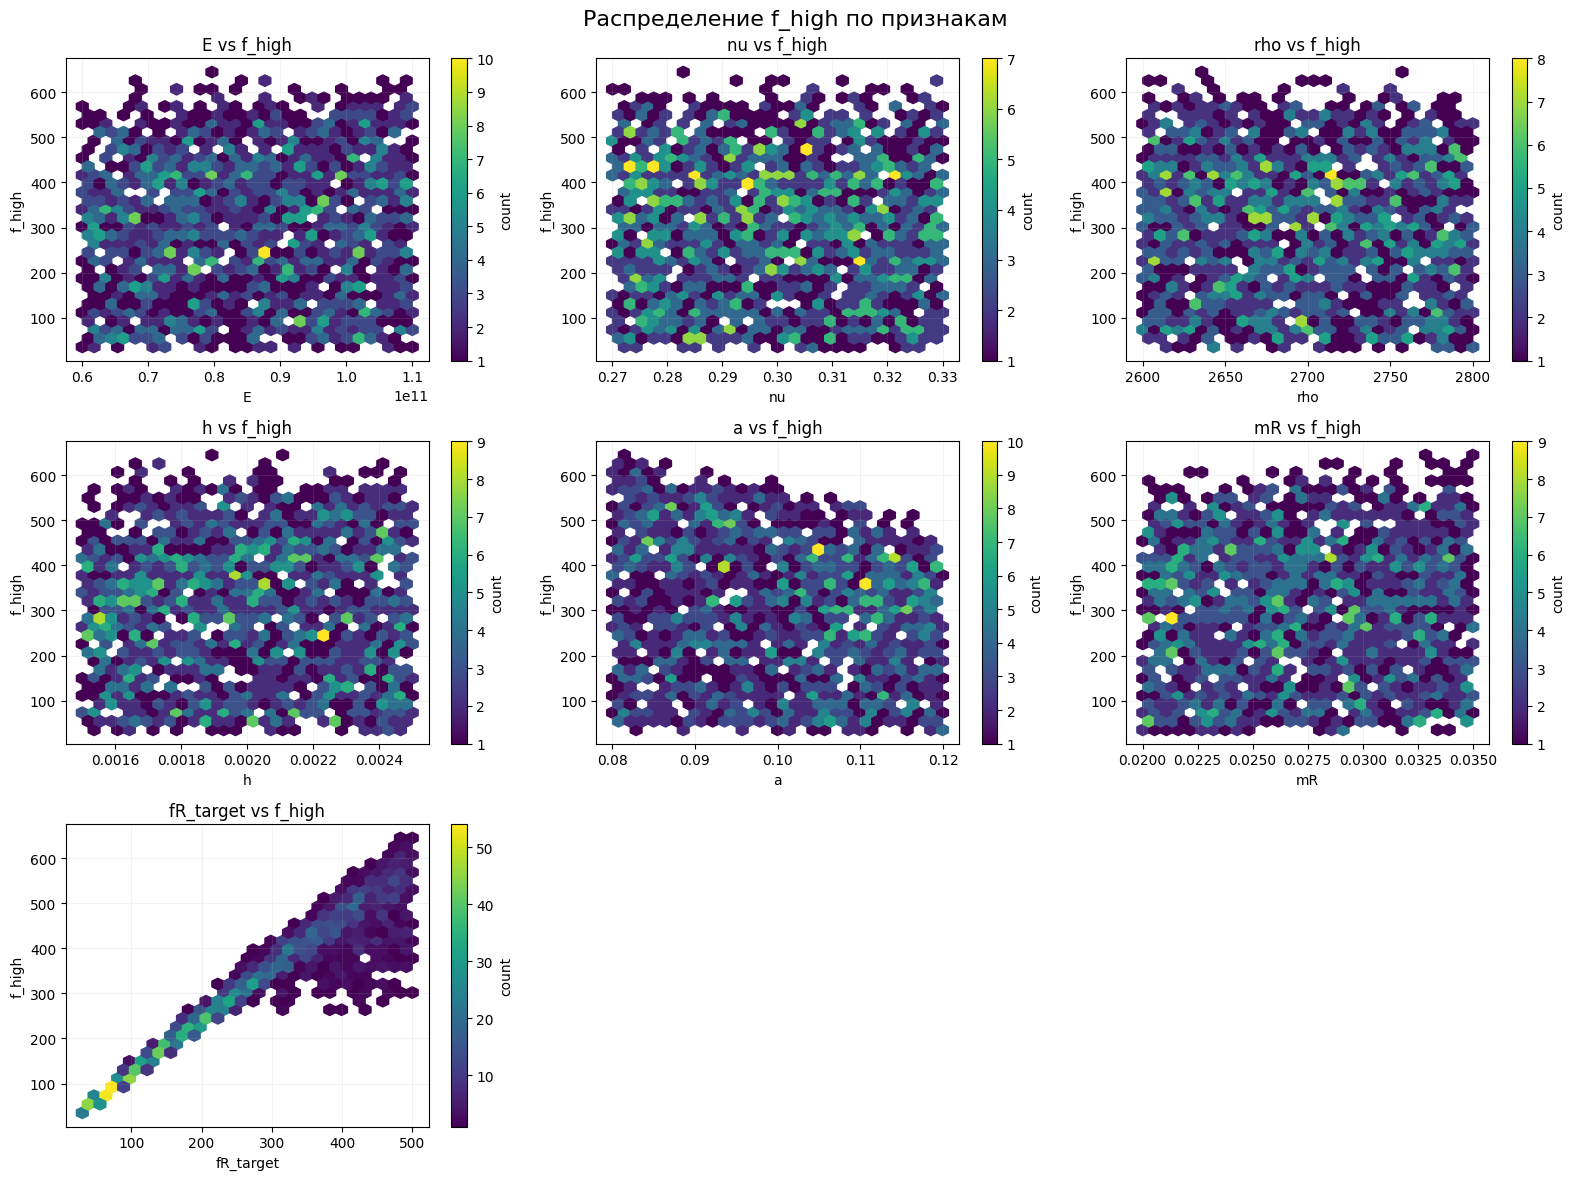

In [10]:
plot_feature_vs_gap_metric(positive_gap_df, "f_high")

In [11]:
def get_dispersion_plot(E = 70e9, nu = 0.3, rho = 2700, h = 0.002, a = 0.1, mR = 0.027, fR_target = 300, f_low=None, f_high=None, M_order=11):
    kR = mR * (2 * np.pi * fR_target) ** 2 

    D_const = (E * h ** 3) / (12 * (1 - nu ** 2))
    S = a**2          
    mass_plate = rho * h * S

    range_M = np.arange(-M_order, M_order + 1)
    GX, GY = np.meshgrid(range_M, range_M)
    GX, GY = GX.flatten() * (2 * np.pi / a), GY.flatten() * (2 * np.pi / a)
    N_waves = len(GX)

    pts = 40
    path_k = np.zeros((3 * pts, 2))
    path_k[0:pts, 0] = np.linspace(0, np.pi/a, pts)
    path_k[pts:2*pts, 0] = np.pi/a                 
    path_k[pts:2*pts, 1] = np.linspace(0, np.pi/a, pts)
    path_k[2*pts:, 0] = np.linspace(np.pi/a, 0, pts)
    path_k[2*pts:, 1] = np.linspace(np.pi/a, 0, pts)

    freqs_lr = []
    freqs_bare = []

    for kx, ky in path_k:
        K_diag = ((kx + GX) ** 2 + (ky + GY) ** 2) ** 2
        K_mat = np.diag(K_diag)
        
        U = np.ones((N_waves, N_waves))
        I = np.eye(N_waves)

        LHS_b = D_const * S * K_mat
        RHS_b = mass_plate * I
        vals_b, _ = eigh(LHS_b, RHS_b)
        freqs_bare.append(np.sqrt(np.maximum(vals_b, 0)) / (2 * np.pi))

        A = np.zeros((N_waves + 1, N_waves + 1))
        A[:N_waves, :N_waves] = D_const * S * K_mat + kR * U
        A[:N_waves, N_waves] = -kR * np.ones(N_waves)
        A[N_waves, :N_waves] = -kR * np.ones(N_waves)
        A[N_waves, N_waves] = kR
        
        B = np.zeros((N_waves + 1, N_waves + 1))
        B[:N_waves, :N_waves] = mass_plate * I
        B[N_waves, N_waves] = mR
        
        vals_lr, _ = eigh(A, B)
        freqs_lr.append(np.sqrt(np.maximum(vals_lr, 0)) / (2 * np.pi))

    freqs_lr = np.array(freqs_lr)
    freqs_bare = np.array(freqs_bare)

    plt.figure(figsize=(10, 7))

    for i in range(8):
        label = 'Bare plate' if i == 0 else ""
        plt.scatter(range(len(path_k)), freqs_bare[:, i], color='blue', s=2, alpha=0.5, label=label)

    for i in range(8):
        label = 'LR plate' if i == 0 else ""
        plt.plot(freqs_lr[:, i], color='black', linewidth=1.5, label=label)

    plt.xlim(0, len(path_k)-1)
    plt.ylim(0, 800)
    plt.ylabel('Frequency (Hz)', fontsize=14)
    plt.title(f'Band Structure (f_R = {fR_target} Hz)', fontsize=16)

    plt.axvline(pts, color='gray', linestyle='--')
    plt.axvline(2 * pts, color='gray', linestyle='--')
    plt.xticks([0, pts, 2 * pts, 3 * pts - 1], [r'$\Gamma$', 'X', 'M', r'$\Gamma$'], fontsize=14)

    if f_low is not None:
        plt.axhline(f_low, color="red", linestyle="--", linewidth=1.5)

    if f_high is not None:
        plt.axhline(f_high, color="red", linestyle="--", linewidth=1.5, label="band gap")

    plt.legend(loc='upper right')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

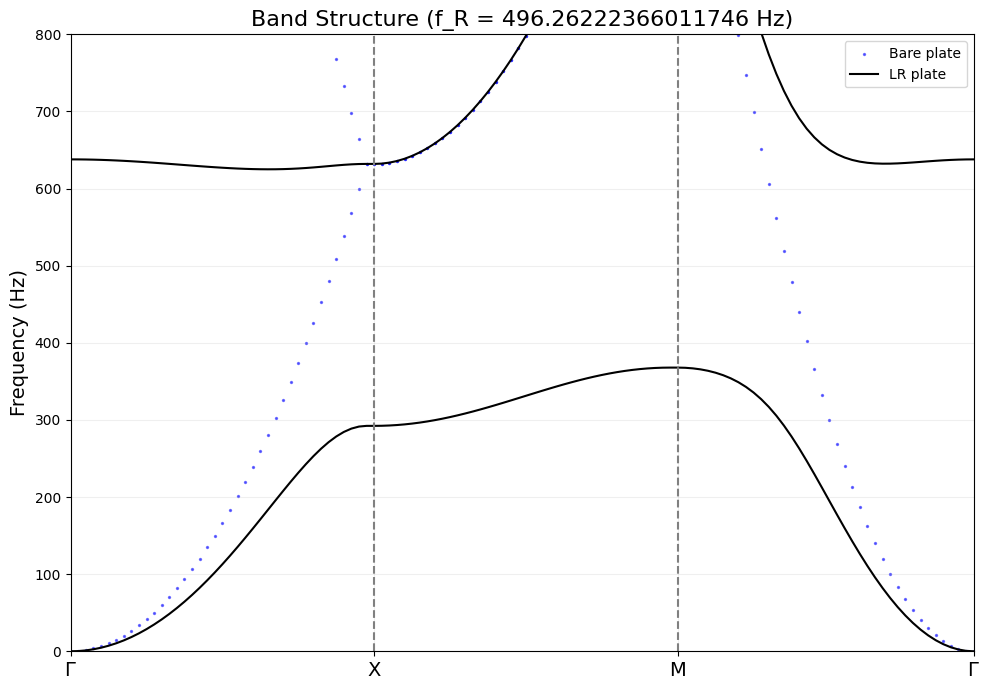

In [12]:
params = positive_gap_df.nlargest(1, "gap_width")[FEATURE_COLS]
params_dict = params.iloc[0].to_dict()
get_dispersion_plot(**params_dict)